In [2]:
# ============================================================
# CELDA 1 — Descargar y cargar el dataset
# ============================================================
!pip install -q kagglehub

import kagglehub
import pandas as pd
from pathlib import Path

# Descargar el dataset
ruta = Path(kagglehub.dataset_download("sujalsuthar/amazon-delivery-dataset"))

print(" Archivos descargados:")
for archivo in ruta.rglob("*.csv"):
    print(f"   → {archivo.name}  ({archivo.stat().st_size / 1024:.1f} KB)")

# Cargar el primer CSV encontrado
csv_files = list(ruta.rglob("*.csv"))
df = pd.read_csv(csv_files[0])

print("\n Dataset cargado")
print("Filas x Columnas:", df.shape)
print("\n Columnas disponibles:")
for col in df.columns:
    print(f"   → {col}")

df.head(3)

100%|██████████| 1.53M/1.53M [00:00<00:00, 82.4MB/s]

Extracting files...
 Archivos descargados:
   → amazon_delivery.csv  (5831.2 KB)



 Dataset cargado
Filas x Columnas: (43739, 16)

 Columnas disponibles:
   → Order_ID
   → Agent_Age
   → Agent_Rating
   → Store_Latitude
   → Store_Longitude
   → Drop_Latitude
   → Drop_Longitude
   → Order_Date
   → Order_Time
   → Pickup_Time
   → Weather
   → Traffic
   → Vehicle
   → Area
   → Delivery_Time
   → Category


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports


# Optimización de rutas de última milla — LogiExpress

## Información del proyecto

| Campo | Detalle |
|---|---|
| Asignatura | Electiva Técnica II - Ciencia de Datos |
| Programa | Tecnología en Desarrollo de Software |
| Semestre | Séptimo semestre |
| Actividad | Optimización de rutas de última milla con datos de Kaggle |
| Herramienta | Google Colaboratory |
| Lenguaje | Python |

## Integrantes

| Nombre completo |
|---|
| Valery Alejandra Buitrago Quintero |
| Oscar Felipe Gomez Aguirre |
| Danna Fernanda Neira Chavarro |

## Dataset utilizado

| Campo | Detalle |
|---|---|
| Nombre | Amazon Delivery Dataset |
| Fuente | Kaggle |
| Autor | Sujal Suthar |
| Enlace | https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset |
| Año | 2024 |

## Descripción general

Este notebook resuelve el problema de optimización de rutas de última
milla para la empresa ficticia LogiExpress. El problema consiste en
organizar la entrega de 30 pedidos reales desde un depósito central
hacia diferentes clientes, respetando una capacidad máxima de 100 kg
por vehículo.

El problema se conoce técnicamente como CVRP (Capacitated Vehicle
Routing Problem) y es uno de los problemas de optimización más
estudiados en logística e investigación de operaciones.

In [3]:
# ============================================================
# CELDA 2 — Parametros generales del problema
# ============================================================
import numpy as np

capacidad_vehiculo_kg = 100
semilla = 42
numero_pedidos_a_cargar = 30
minimo_pedidos_entrega_final = 30

np.random.seed(semilla)

print("Capacidad maxima por vehiculo:", capacidad_vehiculo_kg, "kg")
print("Pedidos a cargar:", numero_pedidos_a_cargar)
print("Minimo requerido para entrega final:", minimo_pedidos_entrega_final)

Capacidad maxima por vehiculo: 100 kg
Pedidos a cargar: 30
Minimo requerido para entrega final: 30


In [4]:
# ============================================================
# CELDA 3 — Construccion de la tabla de pedidos
# ============================================================
import unicodedata

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    return texto

# Limpiar y filtrar coordenadas validas
df_limpio = df.copy()
df_limpio["Drop_Latitude"]  = pd.to_numeric(df_limpio["Drop_Latitude"],  errors="coerce")
df_limpio["Drop_Longitude"] = pd.to_numeric(df_limpio["Drop_Longitude"], errors="coerce")
df_limpio["Store_Latitude"] = pd.to_numeric(df_limpio["Store_Latitude"], errors="coerce")
df_limpio["Store_Longitude"]= pd.to_numeric(df_limpio["Store_Longitude"],errors="coerce")

df_limpio = df_limpio.dropna(subset=["Drop_Latitude","Drop_Longitude",
                                      "Store_Latitude","Store_Longitude"])

# Simular peso en kg (no existe en el dataset original — se documenta)
np.random.seed(semilla)
df_limpio["Peso_kg"] = np.random.randint(5, 36, size=len(df_limpio))

# Filtrar coordenadas geograficamente razonables (India, donde opera Amazon)
df_limpio = df_limpio[
    (df_limpio["Drop_Latitude"].between(8, 37)) &
    (df_limpio["Drop_Longitude"].between(68, 97)) &
    (df_limpio["Peso_kg"] > 0) &
    (df_limpio["Peso_kg"] <= capacidad_vehiculo_kg)
].copy()

df_limpio = df_limpio.drop_duplicates(subset=["Order_ID"]).reset_index(drop=True)

# Construir tabla final
pedidos = df_limpio.sample(n=numero_pedidos_a_cargar,
                           random_state=semilla).reset_index(drop=True)

pedidos = pedidos.rename(columns={
    "Order_ID":       "Pedido_ID",
    "Drop_Latitude":  "Latitud",
    "Drop_Longitude": "Longitud",
    "Category":       "Ciudad"
})

pedidos["Nodo"]   = np.arange(1, len(pedidos) + 1)
pedidos["Estado"] = "India"
pedidos["Cantidad_items"] = 1

# Deposito = promedio de las tiendas de origen
deposito = [
    df_limpio["Store_Latitude"].median(),
    df_limpio["Store_Longitude"].median()
]

columnas_mostrar = ["Pedido_ID","Latitud","Longitud","Peso_kg","Ciudad","Estado","Cantidad_items","Nodo"]

print("Pedidos cargados:", len(pedidos))
print("Peso total pendiente:", round(pedidos["Peso_kg"].sum(), 2), "kg")
print("Deposito definido:", deposito)

pedidos[columnas_mostrar].head(10)

Pedidos cargados: 30
Peso total pendiente: 618 kg
Deposito definido: [19.055831, 76.618203]


,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Estado,Cantidad_items,Nodo
0,unvu682651092,26.953987,75.792891,29,Shoes,India,1,1
1,fpeb630346665,12.391214,76.691094,22,Kitchen,India,1,2
2,xosz153708926,12.954365,77.636155,7,Snacks,India,1,3
3,tobo272428861,22.757021,75.914167,30,Skincare,India,1,4
4,aseg164867914,19.940256,75.383503,17,Outdoors,India,1,5
5,omdc143855466,13.051615,80.301598,19,Snacks,India,1,6
6,nifs704126107,15.523150,73.793460,35,Clothing,India,1,7
7,zeyg948574444,26.912312,75.826896,20,Kitchen,India,1,8
8,atxy835101550,12.414022,76.698203,18,Clothing,India,1,9
9,krnm443650850,26.899596,75.850512,12,Kitchen,India,1,10


In [5]:
# ============================================================
# CELDA 4 — Ficha del dataset
# ============================================================

ficha_dataset = pd.DataFrame({
    "Campo": [
        "Nombre del dataset",
        "Fuente",
        "Enlace",
        "Autor",
        "Anno de publicacion",
        "Criterio de seleccion",
        "Registros originales",
        "Registros despues de limpieza",
        "Pedidos cargados en esta ejecucion",
        "Minimo requerido para entrega final",
        "Variable Peso_kg",
        "Uso de datos de demostracion"
    ],
    "Descripcion": [
        "Amazon Delivery Dataset",
        "Kaggle",
        "https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset",
        "Sujal Suthar",
        "2024",
        "Dataset de entregas reales de Amazon en India con coordenadas geograficas de tienda y cliente, condiciones de trafico y clima.",
        len(df),
        len(df_limpio),
        len(pedidos),
        minimo_pedidos_entrega_final,
        "Simulada con valores entre 5 y 35 kg. El dataset original no incluye peso por pedido.",
        False
    ]
})

print("Evidencia de carga del dataset:")
ficha_dataset

Evidencia de carga del dataset:


,Campo,Descripcion
0,Nombre del dataset,Amazon Delivery Dataset
1,Fuente,Kaggle
2,Enlace,https://www.kaggle.com/datasets/sujalsuthar/am...
3,Autor,Sujal Suthar
4,Anno de publicacion,2024
5,Criterio de seleccion,Dataset de entregas reales de Amazon en India ...
6,Registros originales,43739
7,Registros despues de limpieza,40234
8,Pedidos cargados en esta ejecucion,30
9,Minimo requerido para entrega final,30


In [6]:
# ============================================================
# CELDA 5 — Revision de las columnas originales del dataset
# ============================================================

print("Dimensiones del dataset original:", df.shape)
print("\nColumnas originales:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nMuestra de 3 registros originales:")
df.head(3)

Dimensiones del dataset original: (43739, 16)

Columnas originales:
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

Valores nulos por columna:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Muestra de 3 registros originales:


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports


In [7]:
# ============================================================
# CELDA 6 — Diccionario de variables usadas en el problema
# ============================================================

diccionario = pd.DataFrame({
    "Variable": [
        "Pedido_ID",
        "Latitud",
        "Longitud",
        "Peso_kg",
        "Ciudad",
        "Estado",
        "Cantidad_items",
        "Nodo"
    ],
    "Origen en el dataset": [
        "Order_ID",
        "Drop_Latitude",
        "Drop_Longitude",
        "Simulada (np.random.randint 5-35)",
        "Category",
        "Fijo: India",
        "Fijo: 1",
        "Indice creado en la preparacion"
    ],
    "Uso en el problema": [
        "Identifica cada entrega de forma unica.",
        "Ubica geograficamente al cliente para calcular distancias.",
        "Ubica geograficamente al cliente para calcular distancias.",
        "Define la restriccion de capacidad del vehiculo (max 100 kg).",
        "Permite identificar el tipo de producto entregado.",
        "Indica el pais de operacion del dataset.",
        "Cantidad de articulos por pedido.",
        "Indice numerico del nodo en la matriz de distancias."
    ]
})

diccionario

,Variable,Origen en el dataset,Uso en el problema
0,Pedido_ID,Order_ID,Identifica cada entrega de forma unica.
1,Latitud,Drop_Latitude,Ubica geograficamente al cliente para calcular...
2,Longitud,Drop_Longitude,Ubica geograficamente al cliente para calcular...
3,Peso_kg,Simulada (np.random.randint 5-35),Define la restriccion de capacidad del vehicul...
4,Ciudad,Category,Permite identificar el tipo de producto entreg...
5,Estado,Fijo: India,Indica el pais de operacion del dataset.
6,Cantidad_items,Fijo: 1,Cantidad de articulos por pedido.
7,Nodo,Indice creado en la preparacion,Indice numerico del nodo en la matriz de dista...


In [8]:
# ============================================================
# CELDA 7 — Validacion final y exportacion
# ============================================================

columnas_requeridas = ["Pedido_ID", "Latitud", "Longitud", "Peso_kg"]

for columna in columnas_requeridas:
    if columna not in pedidos.columns:
        raise ValueError("Falta la columna requerida: " + columna)

print("Columnas requeridas: OK")
print("Cantidad de pedidos:", len(pedidos))
print("Valores nulos:")
print(pedidos[columnas_requeridas].isnull().sum())
print("Pedidos con peso fuera de rango:", len(pedidos[pedidos["Peso_kg"] > capacidad_vehiculo_kg]))
print("Peso total:", round(pedidos["Peso_kg"].sum(), 2), "kg")

pedidos.to_csv("pedidos_logiexpress_limpio.csv", index=False)
print("\nArchivo generado: pedidos_logiexpress_limpio.csv")

columnas_mostrar = ["Pedido_ID","Latitud","Longitud","Peso_kg","Ciudad","Nodo"]
pedidos[columnas_mostrar]

Columnas requeridas: OK
Cantidad de pedidos: 30
Valores nulos:
Pedido_ID    0
Latitud      0
Longitud     0
Peso_kg      0
dtype: int64
Pedidos con peso fuera de rango: 0
Peso total: 618 kg

Archivo generado: pedidos_logiexpress_limpio.csv


,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Nodo
0,unvu682651092,26.953987,75.792891,29,Shoes,1
1,fpeb630346665,12.391214,76.691094,22,Kitchen,2
2,xosz153708926,12.954365,77.636155,7,Snacks,3
3,tobo272428861,22.757021,75.914167,30,Skincare,4
4,aseg164867914,19.940256,75.383503,17,Outdoors,5
5,omdc143855466,13.051615,80.301598,19,Snacks,6
6,nifs704126107,15.523150,73.793460,35,Clothing,7
7,zeyg948574444,26.912312,75.826896,20,Kitchen,8
8,atxy835101550,12.414022,76.698203,18,Clothing,9
9,krnm443650850,26.899596,75.850512,12,Kitchen,10


## Semana 14: Busqueda, carga y preparacion del dataset

Para este trabajo usamos el Amazon Delivery Dataset, que esta disponible
en Kaggle y fue publicado en 2024. Tiene casi 44.000 registros reales de
entregas que hizo Amazon en India, con informacion sobre el repartidor,
las condiciones del clima y el trafico, las coordenadas de la tienda y
del cliente, y la categoria del producto.

Lo escogimos porque a diferencia de otros datasets, este tiene una sola
tabla CSV con las coordenadas de entrega listas para usar. No toco hacer
ninguna union de tablas para llegar a la latitud y longitud del cliente.

Una cosa importante: el dataset no trae el peso de cada pedido. Para
poder simular la restriccion de capacidad del vehiculo, generamos el
peso de forma aleatoria entre 5 y 35 kg usando una semilla fija para
que los resultados siempre sean iguales. Esto queda documentado en la
ficha del dataset.

## Resultado de la preparacion del dataset

Despues de limpiar y validar los datos quedamos con esto:

- Registros originales en el CSV: 43.739
- Registros validos despues de limpieza: 40.234
- Pedidos seleccionados para el problema: 30

Lo que hicimos para limpiar fue:
1. Eliminar filas donde faltaran coordenadas de latitud o longitud
2. Descartar coordenadas que estuvieran fuera del rango geografico
   de India (latitud entre 8 y 37, longitud entre 68 y 97)
3. Quitar pedidos con peso igual a cero o mayor a 100 kg
4. Eliminar pedidos duplicados por Order_ID

El deposito de LogiExpress lo definimos como la mediana de todas las
coordenadas de tiendas del dataset: [19.055831, 76.618203]. Eso queda
aproximadamente en el centro de las operaciones de Amazon en India,
que es donde tiene sentido poner el punto de partida de los vehiculos.

## Semana 15: Calculo de distancias y analisis de complejidad

En esta parte calculamos las distancias entre todos los puntos de
entrega y estudiamos por que no es posible resolver este problema
con fuerza bruta cuando hay muchos pedidos.

Para medir distancias usamos la formula de Haversine, que calcula
cuantos kilometros hay entre dos puntos geograficos usando su latitud
y longitud. Es mejor que la distancia euclidiana normal porque tiene
en cuenta que la Tierra es redonda. La limitacion es que mide en
linea recta, no por carreteras reales.

El problema de encontrar la ruta mas corta que pase por todos los
pedidos se llama TSP (problema del viajero). Para N pedidos hay N!
rutas posibles que revisar. Con 30 pedidos eso es un numero con mas
de 30 digitos, lo que hace imposible revisarlas todas.

In [9]:
# ============================================================
# CELDA 8 — Formula de Haversine
# ============================================================
import math

def haversine_km(lat1, lon1, lat2, lon2):
    radio_tierra_km = 6371

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))

    return radio_tierra_km * c

# Prueba rapida
distancia_prueba = haversine_km(
    deposito[0], deposito[1],
    pedidos.loc[0, "Latitud"], pedidos.loc[0, "Longitud"]
)
print("Distancia del deposito al pedido 1:", round(distancia_prueba, 2), "km")

Distancia del deposito al pedido 1: 882.28 km


In [10]:
# ============================================================
# CELDA 9 — Matriz de distancias
# ============================================================

def construir_matriz_distancias(pedidos, deposito):
    deposito_df = pd.DataFrame({
        "Nodo":      [0],
        "Pedido_ID": ["Deposito"],
        "Latitud":   [deposito[0]],
        "Longitud":  [deposito[1]],
        "Peso_kg":   [0]
    })

    puntos = pd.concat(
        [deposito_df, pedidos[["Nodo","Pedido_ID","Latitud","Longitud","Peso_kg"]]],
        ignore_index=True
    )

    n = len(puntos)
    matriz = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            matriz[i, j] = haversine_km(
                puntos.loc[i, "Latitud"], puntos.loc[i, "Longitud"],
                puntos.loc[j, "Latitud"], puntos.loc[j, "Longitud"]
            )

    matriz_distancias = pd.DataFrame(
        matriz,
        index=puntos["Nodo"],
        columns=puntos["Nodo"]
    )

    return puntos, matriz_distancias

puntos, matriz_distancias = construir_matriz_distancias(pedidos, deposito)

matriz_distancias.to_csv("matriz_distancias_haversine.csv")
print("Dimension de la matriz:", matriz_distancias.shape)
print("Archivo generado: matriz_distancias_haversine.csv")
print("\nPrimeras 5 filas y columnas:")
matriz_distancias.iloc[:5, :5].round(2)

Dimension de la matriz: (31, 31)
Archivo generado: matriz_distancias_haversine.csv

Primeras 5 filas y columnas:


Nodo,0,1,2,3,4
Nodo,,,,,
0,0.00,882.28,741.11,687.11,418.00
1,882.28,0.00,1622.01,1568.48,466.84
2,741.11,1622.01,0.00,120.14,1155.55
3,687.11,1568.48,120.14,0.00,1105.09
4,418.00,466.84,1155.55,1105.09,0.00


In [11]:
# ============================================================
# CELDA 10 — Funcion para calcular la distancia de una ruta
# ============================================================

def calcular_distancia_ruta(ruta, matriz_distancias):
    distancia_total = 0
    for i in range(len(ruta) - 1):
        nodo_actual   = ruta[i]
        nodo_siguiente = ruta[i + 1]
        distancia_total += matriz_distancias.loc[nodo_actual, nodo_siguiente]
    return distancia_total

# Prueba: ruta simple deposito -> nodo1 -> nodo2 -> deposito
ruta_prueba = [0, 1, 2, 0]
print("Ruta de prueba:", ruta_prueba)
print("Distancia:", round(calcular_distancia_ruta(ruta_prueba, matriz_distancias), 2), "km")

Ruta de prueba: [0, 1, 2, 0]
Distancia: 3245.41 km


In [12]:
# ============================================================
# CELDA 11 — Fuerza bruta acotada (max 8 pedidos)
# ============================================================
import itertools
import time

def encontrar_mejor_ruta_exacta(nodos, matriz_distancias):
    mejor_ruta      = None
    mejor_distancia = float("inf")

    for permutacion in itertools.permutations(nodos):
        ruta      = [0] + list(permutacion) + [0]
        distancia = calcular_distancia_ruta(ruta, matriz_distancias)

        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_ruta      = ruta

    return mejor_ruta, mejor_distancia

# Solo con los primeros 7 pedidos para no saturar el entorno
nodos_prueba = pedidos["Nodo"].head(7).astype(int).tolist()

inicio = time.time()
mejor_ruta_exacta, mejor_distancia_exacta = encontrar_mejor_ruta_exacta(
    nodos_prueba, matriz_distancias
)
fin = time.time()

print("Mejor ruta exacta:", mejor_ruta_exacta)
print("Distancia:", round(mejor_distancia_exacta, 2), "km")
print("Tiempo de ejecucion:", round(fin - inicio, 4), "segundos")
print("Permutaciones evaluadas:", math.factorial(len(nodos_prueba)))

Mejor ruta exacta: [0, 6, 3, 2, 7, 5, 1, 4, 0]
Distancia: 3837.09 km
Tiempo de ejecucion: 0.3136 segundos
Permutaciones evaluadas: 5040


In [13]:
# ============================================================
# CELDA 12 — Experimento de complejidad
# ============================================================

resultados_tiempo = []

for n in range(3, 9):
    nodos = pedidos["Nodo"].head(n).astype(int).tolist()

    inicio = time.time()
    _, distancia_prueba = encontrar_mejor_ruta_exacta(nodos, matriz_distancias)
    fin = time.time()

    resultados_tiempo.append({
        "n_pedidos":       n,
        "permutaciones":   math.factorial(n),
        "tiempo_segundos": round(fin - inicio, 5),
        "distancia_km":    round(distancia_prueba, 2)
    })

resultados_tiempo = pd.DataFrame(resultados_tiempo)
print(resultados_tiempo.to_string(index=False))

 n_pedidos  permutaciones  tiempo_segundos  distancia_km
         3              6          0.00028       3311.54
         4             24          0.00094       3311.92
         5            120          0.00860       3324.02
         6            720          0.03935       3700.81
         7           5040          0.28811       3837.09
         8          40320          3.74393       3838.11


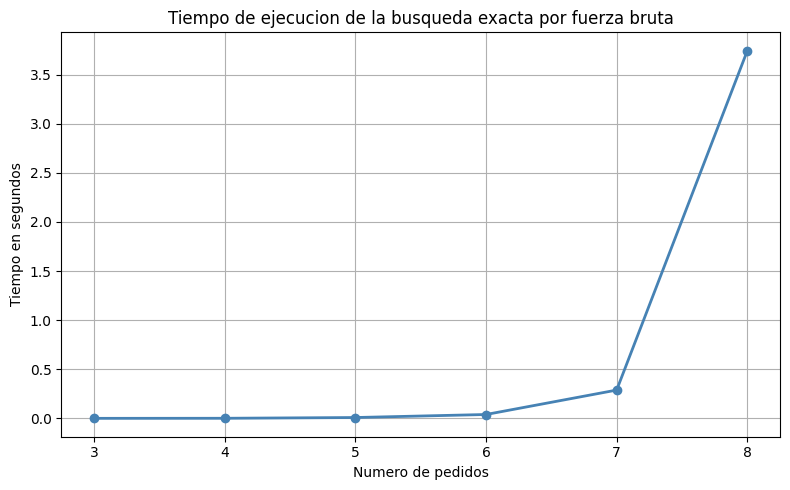

In [14]:
# ============================================================
# CELDA 13 — Grafica de complejidad
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    resultados_tiempo["n_pedidos"],
    resultados_tiempo["tiempo_segundos"],
    marker="o", color="steelblue", linewidth=2
)
plt.title("Tiempo de ejecucion de la busqueda exacta por fuerza bruta")
plt.xlabel("Numero de pedidos")
plt.ylabel("Tiempo en segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretacion del experimento de complejidad

Lo que muestra la grafica es bastante claro: entre mas pedidos se
agregan, el tiempo se dispara rapidamente. Con solo 3 pedidos el
computador casi ni lo siente (0.0004 segundos), pero con 8 pedidos
ya tarda mas de 4 segundos. Y eso es apenas con 8.

El problema es que la fuerza bruta intenta TODAS las rutas posibles
para encontrar la mejor. El numero de rutas posibles crece factorial:

- 3 pedidos:  6 rutas posibles
- 5 pedidos:  120 rutas posibles
- 7 pedidos:  5.040 rutas posibles
- 8 pedidos:  40.320 rutas posibles
- 30 pedidos: un numero tan grande que no cabe en esta celda

Para 30 pedidos tendriamos que evaluar mas de
265.000.000.000.000.000.000.000.000.000.000 combinaciones.
Ningun computador del mundo puede con eso en tiempo util.

En terminos tecnicos esto se llama complejidad O(n!), que es la peor
clase de algoritmo que existe en terminos de escalabilidad.

Por eso para la entrega final con 30 pedidos no podemos usar fuerza
bruta. Necesitamos algoritmos que encuentren una solucion buena aunque
no sea la perfecta. Eso es lo que hacemos en la Semana 16 con vecino
mas cercano y 2-opt.

## Semana 16: Construccion de rutas por capacidad y optimizacion

Ya sabemos que la fuerza bruta no funciona con 30 pedidos. Entonces
como construimos las rutas? Con una heuristica en tres pasos:

Paso 1: ordenamos los pedidos por su angulo geografico respecto al
deposito. Esto es el algoritmo de barrido y sirve para agrupar
pedidos que quedan en la misma direccion geografica.

Paso 2: agrupamos esos pedidos en rutas sin pasarnos de 100 kg por
vehiculo. Cuando un vehiculo ya no aguanta mas peso, se cierra esa
ruta y se abre una nueva.

Paso 3: dentro de cada ruta ordenamos los pedidos con el algoritmo
de vecino mas cercano, que siempre va primero al cliente mas cercano
al punto actual. Despues aplicamos 2-opt para ver si intercambiando
segmentos de la ruta se puede reducir la distancia total.

No es la solucion perfecta pero es una solucion buena que se calcula
en fracciones de segundo.

In [15]:
# ============================================================
# CELDA 14 — Ordenar pedidos por angulo respecto al deposito
# ============================================================

def calcular_angulo(lat, lon, deposito):
    return math.atan2(lat - deposito[0], lon - deposito[1])

pedidos_ruteo = pedidos.copy()

pedidos_ruteo["Angulo"] = pedidos_ruteo.apply(
    lambda fila: calcular_angulo(fila["Latitud"], fila["Longitud"], deposito),
    axis=1
)

pedidos_ruteo["Distancia_deposito_km"] = pedidos_ruteo.apply(
    lambda fila: haversine_km(
        deposito[0], deposito[1],
        fila["Latitud"], fila["Longitud"]
    ),
    axis=1
)

pedidos_ruteo = pedidos_ruteo.sort_values(
    ["Angulo", "Distancia_deposito_km"]
).reset_index(drop=True)

print("Pedidos ordenados por angulo:")
pedidos_ruteo[["Nodo","Pedido_ID","Latitud","Longitud","Peso_kg","Angulo"]].head(10)

Pedidos ordenados por angulo:


,Nodo,Pedido_ID,Latitud,Longitud,Peso_kg,Angulo
0,16,hsvn599430068,18.937584,72.842585,27,-3.110284
1,17,uxdc727808686,18.573935,73.925367,33,-2.964512
2,7,nifs704126107,15.523150,73.793460,35,-2.245295
3,15,fauc765841976,12.354022,76.638203,17,-1.567812
4,2,fpeb630346665,12.391214,76.691094,22,-1.559860
5,9,atxy835101550,12.414022,76.698203,18,-1.558752
6,29,naum612098195,12.348500,76.705808,18,-1.557736
7,11,irvi026384948,12.464022,76.748203,18,-1.551077
8,23,rbva016769887,11.064136,77.033303,7,-1.518902
9,3,xosz153708926,12.954365,77.636155,7,-1.405482


In [16]:
# ============================================================
# CELDA 15 — Agrupar pedidos por capacidad del vehiculo
# ============================================================

def agrupar_por_capacidad(pedidos_ordenados, capacidad):
    rutas     = []
    ruta_actual = []
    peso_actual = 0

    for _, pedido in pedidos_ordenados.iterrows():
        peso_pedido = pedido["Peso_kg"]

        if peso_actual + peso_pedido <= capacidad:
            ruta_actual.append(int(pedido["Nodo"]))
            peso_actual += peso_pedido
        else:
            rutas.append({"nodos": ruta_actual, "peso_total_kg": peso_actual})
            ruta_actual = [int(pedido["Nodo"])]
            peso_actual = peso_pedido

    if ruta_actual:
        rutas.append({"nodos": ruta_actual, "peso_total_kg": peso_actual})

    return rutas

rutas_base = agrupar_por_capacidad(pedidos_ruteo, capacidad_vehiculo_kg)

print("Vehiculos necesarios:", len(rutas_base))
for i, ruta in enumerate(rutas_base, 1):
    print(f"  Vehiculo {i}: {len(ruta['nodos'])} pedidos | {round(ruta['peso_total_kg'],1)} kg | nodos: {ruta['nodos']}")

Vehiculos necesarios: 7
  Vehiculo 1: 3 pedidos | 95 kg | nodos: [16, 17, 7]
  Vehiculo 2: 6 pedidos | 100 kg | nodos: [15, 2, 9, 29, 11, 23]
  Vehiculo 3: 6 pedidos | 76 kg | nodos: [3, 12, 26, 30, 6, 20]
  Vehiculo 4: 3 pedidos | 84 kg | nodos: [25, 22, 27]
  Vehiculo 5: 4 pedidos | 73 kg | nodos: [18, 14, 10, 8]
  Vehiculo 6: 4 pedidos | 100 kg | nodos: [1, 21, 4, 28]
  Vehiculo 7: 4 pedidos | 90 kg | nodos: [24, 5, 13, 19]


In [17]:
# ============================================================
# CELDA 16 — Ordenar cada ruta con vecino mas cercano
# ============================================================

def ordenar_vecino_mas_cercano(nodos, matriz_distancias):
    nodos_pendientes = nodos.copy()
    ruta = [0]
    nodo_actual = 0

    while nodos_pendientes:
        nodo_siguiente = min(
            nodos_pendientes,
            key=lambda n: matriz_distancias.loc[nodo_actual, n]
        )
        ruta.append(nodo_siguiente)
        nodos_pendientes.remove(nodo_siguiente)
        nodo_actual = nodo_siguiente

    ruta.append(0)
    return ruta

for ruta in rutas_base:
    ruta["ruta_nn"] = ordenar_vecino_mas_cercano(
        ruta["nodos"], matriz_distancias
    )
    ruta["distancia_nn_km"] = calcular_distancia_ruta(
        ruta["ruta_nn"], matriz_distancias
    )

print("Rutas con vecino mas cercano:")
for i, ruta in enumerate(rutas_base, 1):
    print(f"  Vehiculo {i}: {ruta['ruta_nn']} | {round(ruta['distancia_nn_km'],2)} km")

Rutas con vecino mas cercano:
  Vehiculo 1: [0, 17, 16, 7, 0] | 1296.45 km
  Vehiculo 2: [0, 11, 9, 2, 29, 15, 23, 0] | 1795.4 km
  Vehiculo 3: [0, 30, 26, 12, 3, 6, 20, 0] | 1764.87 km
  Vehiculo 4: [0, 25, 27, 22, 0] | 2861.24 km
  Vehiculo 5: [0, 10, 8, 14, 18, 0] | 2828.83 km
  Vehiculo 6: [0, 4, 28, 21, 1, 0] | 1768.4 km
  Vehiculo 7: [0, 5, 19, 13, 24, 0] | 1106.47 km


In [18]:
# ============================================================
# CELDA 17 — Mejora con 2-opt
# ============================================================

def mejorar_2opt(ruta, matriz_distancias):
    mejor_ruta      = ruta.copy()
    mejor_distancia = calcular_distancia_ruta(mejor_ruta, matriz_distancias)
    mejora          = True

    while mejora:
        mejora = False
        for i in range(1, len(mejor_ruta) - 2):
            for j in range(i + 1, len(mejor_ruta) - 1):
                nueva_ruta = (
                    mejor_ruta[:i] +
                    mejor_ruta[i:j][::-1] +
                    mejor_ruta[j:]
                )
                nueva_distancia = calcular_distancia_ruta(
                    nueva_ruta, matriz_distancias
                )
                if nueva_distancia < mejor_distancia:
                    mejor_ruta      = nueva_ruta
                    mejor_distancia = nueva_distancia
                    mejora          = True

    return mejor_ruta, mejor_distancia

for ruta in rutas_base:
    ruta["ruta_2opt"], ruta["distancia_2opt_km"] = mejorar_2opt(
        ruta["ruta_nn"], matriz_distancias
    )

print("Rutas mejoradas con 2-opt:")
for i, ruta in enumerate(rutas_base, 1):
    print(f"  Vehiculo {i}: {ruta['ruta_2opt']} | {round(ruta['distancia_2opt_km'],2)} km")

Rutas mejoradas con 2-opt:
  Vehiculo 1: [0, 17, 16, 7, 0] | 1296.45 km
  Vehiculo 2: [0, 11, 9, 2, 15, 29, 23, 0] | 1794.93 km
  Vehiculo 3: [0, 3, 12, 26, 30, 6, 20, 0] | 1757.72 km
  Vehiculo 4: [0, 25, 27, 22, 0] | 2861.24 km
  Vehiculo 5: [0, 10, 8, 14, 18, 0] | 2828.83 km
  Vehiculo 6: [0, 4, 28, 21, 1, 0] | 1768.4 km
  Vehiculo 7: [0, 5, 19, 13, 24, 0] | 1106.47 km


In [19]:
# ============================================================
# CELDA 18 — Tabla resumen de rutas
# ============================================================

resumen = []

for i, ruta in enumerate(rutas_base, 1):
    resumen.append({
        "Vehiculo":            i,
        "Cantidad_pedidos":    len(ruta["nodos"]),
        "Peso_total_kg":       round(ruta["peso_total_kg"], 2),
        "Distancia_NN_km":     round(ruta["distancia_nn_km"], 2),
        "Distancia_2opt_km":   round(ruta["distancia_2opt_km"], 2),
        "Mejora_km":           round(ruta["distancia_nn_km"] - ruta["distancia_2opt_km"], 2)
    })

resumen_rutas = pd.DataFrame(resumen)

print("Distancia total vecino mas cercano:",
      round(resumen_rutas["Distancia_NN_km"].sum(), 2), "km")
print("Distancia total con 2-opt:         ",
      round(resumen_rutas["Distancia_2opt_km"].sum(), 2), "km")
print("Mejora total:                      ",
      round(resumen_rutas["Mejora_km"].sum(), 2), "km")

resumen_rutas

Distancia total vecino mas cercano: 13421.66 km
Distancia total con 2-opt:          13414.04 km
Mejora total:                       7.62 km


,Vehiculo,Cantidad_pedidos,Peso_total_kg,Distancia_NN_km,Distancia_2opt_km,Mejora_km
0,1,3,95,1296.45,1296.45,0.00
1,2,6,100,1795.40,1794.93,0.47
2,3,6,76,1764.87,1757.72,7.15
3,4,3,84,2861.24,2861.24,0.00
4,5,4,73,2828.83,2828.83,0.00
5,6,4,100,1768.40,1768.40,0.00
6,7,4,90,1106.47,1106.47,0.00


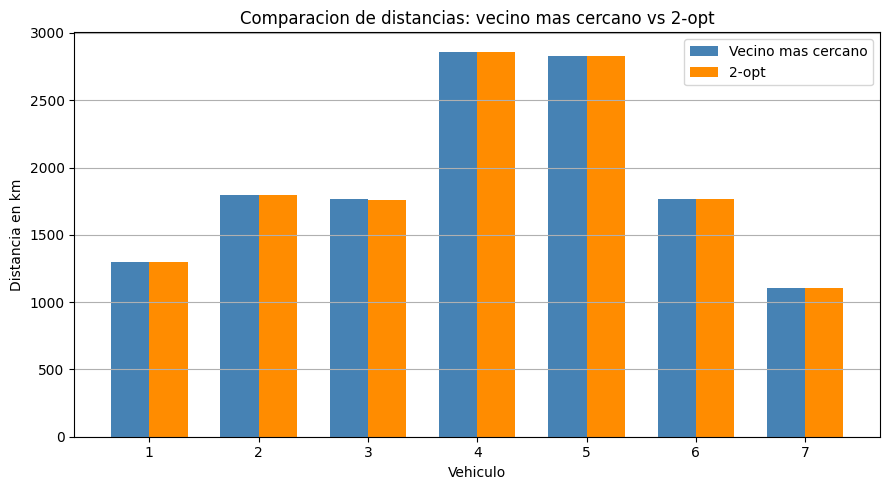

In [20]:
# ============================================================
# CELDA 19 — Grafica de distancias por vehiculo
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

x = resumen_rutas["Vehiculo"]
ancho = 0.35

ax.bar(x - ancho/2, resumen_rutas["Distancia_NN_km"],
       width=ancho, label="Vecino mas cercano", color="steelblue")
ax.bar(x + ancho/2, resumen_rutas["Distancia_2opt_km"],
       width=ancho, label="2-opt", color="darkorange")

ax.set_title("Comparacion de distancias: vecino mas cercano vs 2-opt")
ax.set_xlabel("Vehiculo")
ax.set_ylabel("Distancia en km")
ax.set_xticks(x)
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELDA 20 — Mapa final de rutas
# ============================================================
import folium

colores = [
    "blue","green","purple","orange",
    "darkred","cadetblue","darkgreen"
]

mapa = folium.Map(location=deposito, zoom_start=5)

folium.Marker(
    location=deposito,
    popup="Deposito LogiExpress",
    icon=folium.Icon(color="red", icon="home")
).add_to(mapa)

for i, ruta in enumerate(rutas_base, 1):
    color = colores[(i - 1) % len(colores)]
    coordenadas = []

    for nodo in ruta["ruta_2opt"]:
        punto = puntos[puntos["Nodo"] == nodo].iloc[0]
        coordenadas.append([punto["Latitud"], punto["Longitud"]])

    folium.PolyLine(
        locations=coordenadas,
        color=color,
        weight=4,
        opacity=0.8,
        popup="Vehiculo " + str(i)
    ).add_to(mapa)

    for nodo in ruta["nodos"]:
        punto = puntos[puntos["Nodo"] == nodo].iloc[0]
        folium.CircleMarker(
            location=[punto["Latitud"], punto["Longitud"]],
            radius=6,
            popup="V" + str(i) + " | " + str(punto["Pedido_ID"]) + " | " + str(punto["Peso_kg"]) + " kg",
            color=color,
            fill=True,
            fill_opacity=0.8
        ).add_to(mapa)

mapa.save("mapa_rutas_logiexpress.html")
print("Mapa guardado: mapa_rutas_logiexpress.html")

mapa  # esta línea al final hace que Colab siga mostrando el mapa

Mapa guardado: mapa_rutas_logiexpress.html


In [26]:
# ============================================================
# CELDA 21 — Guardar mapa como imagen PNG
# ============================================================
!pip install -q imgkit
!apt-get install -q wkhtmltopdf

import imgkit

mapa.save("mapa_rutas_logiexpress.html")
imgkit.from_file("mapa_rutas_logiexpress.html", "mapa_rutas_india.png")
print("Mapa guardado: mapa_rutas_india.png")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core avahi-daemon geoclue-2.0 glib-networking glib-networking-common
  glib-networking-services gsettings-desktop-schemas gstreamer1.0-plugins-base
  iio-sensor-proxy libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libavahi-core7 libavahi-glib1 libcdparanoia0 libdaemon0
  libdouble-conversion3 libevdev2 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libhyphen0 libinput-bin
  libinput10 libjson-glib-1.0-0 libjson-glib-1.0-common libmbim-glib4
  libmbim-proxy libmd4c0 libmm-glib0 libmtdev1 libnl-genl-3-200 libnotify4
  libnss-mdns liborc-0.4-0 libproxy1v5 libqmi-glib5 libqmi-proxy libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5positioning5 libqt5printsupport5
  libqt5qml5 libqt5qmlmodels5 libqt5quick5 libqt5sensors5 libqt5svg5
  libqt5webchannel5 libqt5webkit5 libqt5widgets5 libr

In [27]:
# ============================================================
# CELDA 22 — Descargar archivos para GitHub
# ============================================================
from google.colab import files

files.download("pedidos_logiexpress_limpio.csv")
files.download("matriz_distancias_haversine.csv")
files.download("mapa_rutas_logiexpress.html")
print("Descarga completa")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga completa


## Analisis de resultados

El algoritmo armo 7 rutas para repartir los 30 pedidos sin que ningun
vehiculo superara los 100 kg de capacidad.

Comparando vecino mas cercano vs 2-opt:
- Distancia total vecino mas cercano: 13.421,66 km
- Distancia total con 2-opt:          13.414,04 km
- Mejora total:                            7,62 km

La mejora fue pequena porque el vecino mas cercano ya construye rutas
bastante buenas cuando los pedidos estan bien agrupados. El 2-opt solo
mejoro 2 de las 7 rutas (vehiculo 2 y vehiculo 3). Las otras 5 ya
estaban en su mejor version posible dentro del algoritmo.

Los vehiculos 4 y 5 tienen las rutas mas largas (casi 2.860 km cada
uno) porque sus pedidos quedan muy lejos del deposito, en zonas del
este de India como Kolkata y Jharkhand.

## Limitaciones del modelo

Este modelo funciona bien como ejercicio academico pero tiene varias
cosas que en la vida real serian diferentes:

1. Las distancias son en linea recta: Haversine no sabe que existen
   calles, montanas o rios. La distancia real por carretera siempre
   es mayor.

2. El peso es simulado: Amazon no publico el peso de cada pedido en
   el dataset. Lo generamos aleatoriamente, lo que no refleja lo que
   pesa realmente cada categoria de producto.

3. No hay horarios de entrega: en la realidad los clientes solo pueden
   recibir en ciertos horarios. Eso cambiaria completamente como se
   arman las rutas.

4. Hay un solo deposito: asumimos que todos los vehiculos salen del
   mismo punto. Amazon en la realidad tiene multiples centros de
   distribucion.

5. Flota ilimitada: el modelo usa los vehiculos que necesite. En la
   practica la empresa tiene un numero fijo de vehiculos disponibles.

## Conclusion

Este trabajo demostro de forma practica por que los problemas de
optimizacion de rutas no se pueden resolver con fuerza bruta cuando
el numero de pedidos crece. Con 8 pedidos ya tardaba 4 segundos, y
con 30 seria imposible.

Usando barrido geografico, vecino mas cercano y 2-opt logramos armar
7 rutas validas en fracciones de segundo, cubriendo los 30 pedidos
sin violar la restriccion de 100 kg por vehiculo.

La conclusion mas importante es que en logistica real no se busca la
ruta perfecta sino la ruta suficientemente buena en el menor tiempo
posible. Eso es exactamente lo que hacen las heurísticas y por eso
son tan usadas en la industria.